In [9]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
import os #Accede a los archivos del sistema

In [11]:
ruta_train = 'Datasets/Covid19-dataset/train/'
ruta_test = 'Datasets/Covid19-dataset/test/'

In [12]:
clases = os.listdir(ruta_test)
clases

['Normal', 'Covid', 'Viral Pneumonia']

In [13]:
generator = ImageDataGenerator(rescale = 1/255)

In [15]:
x_train = generator.flow_from_directory(
    ruta_train,
    target_size = (512, 512),
    batch_size = 16,
    class_mode = 'categorical'
)

Found 251 images belonging to 3 classes.


In [16]:
x_test = generator.flow_from_directory(
    ruta_test,
    target_size = (512, 512),
    batch_size = 1,
    class_mode = 'categorical'
)

Found 66 images belonging to 3 classes.


In [25]:
modelo = Sequential()
modelo.add(Input(shape = (512,512,3)))
modelo.add(Conv2D(16, kernel_size = 3, padding = 'same', activation = 'relu')) #3x3
modelo.add(MaxPooling2D(pool_size = (2,2)))
modelo.add(Conv2D(64, kernel_size = 3, padding = 'same', activation = 'relu')) #3x3
modelo.add(MaxPooling2D(pool_size = (2,2)))
modelo.add(Conv2D(64, kernel_size = 3 activation = 'relu')) #3x3
modelo.add(MaxPooling2D(pool_size = (2,2)))
modelo.add(Conv2D(128, kernel_size = 3, padding = 'same', activation = 'relu')) #3x3
modelo.add(MaxPooling2D(pool_size = (2,2)))
modelo.add(Flatten())
modelo.add(Dense(128, activation = 'relu'))
modelo.add(Dense(128, activation = 'relu'))
modelo.add(Dense(3, activation = 'softmax'))

SyntaxError: invalid syntax. Perhaps you forgot a comma? (580944147.py, line 7)

In [22]:
modelo.compile(optimizer = 'adam',
               loss = 'categorical_crossentropy', 
               metrics = ['accuracy'])

In [24]:
historia = modelo.fit(x_train, epochs = 12, validation_data = x_test, batch_size = 64) #callbacks = [stop]

/home/fisica8/anaconda3/envs/David_Luque/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 68s 4s/step - accuracy: 0.5621 - loss: 2.1592 - val_accuracy: 0.6970 - val_loss: 0.7732
Epoch 2/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step - accuracy: 0.8936 - loss: 0.3176 - val_accuracy: 0.9545 - val_loss: 0.1514
Epoch 3/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 59s 4s/step - accuracy: 0.9521 - loss: 0.1222 - val_accuracy: 0.8333 - val_loss: 0.4364
Epoch 4/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 59s 4s/step - accuracy: 0.9932 - loss: 0.0472 - val_accuracy: 0.8939 - val_loss: 0.3267
Epoch 5/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 60s 4s/step - accuracy: 0.9890 - loss: 0.0282 - val_accuracy: 0.8788 - val_loss: 0.2931
Epoch 6/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 0.9394 - val_loss: 0.1303
Epoch 7/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9697 - val_loss: 0.1162
Epoch 8/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9394 - val_loss:

In [ ]:
#stop = tf.keras.callbacks.EarlyStopping(monitor = 'loss', patience = 10)

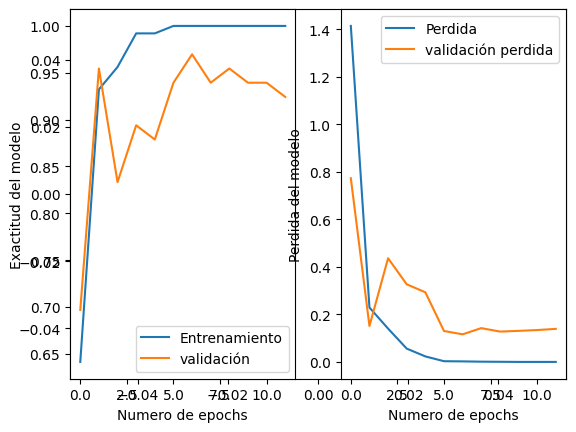

In [34]:
plt.plot(figsize = (12,6))
plt.subplot(1,2,1)
plt.plot(historia.history["accuracy"], label = 'Entrenamiento')
plt.plot(historia.history['val_accuracy'], label = 'validación')
plt.xlabel("Numero de epochs")
plt.ylabel('Exactitud del modelo')
plt.legend()

plt.subplot(1,2,2)
plt.plot(historia.history["loss"], label = 'Perdida')
plt.plot(historia.history['val_loss'], label = 'validación perdida')
plt.xlabel("Numero de epochs")
plt.ylabel('Perdida del modelo')
plt.legend()


plt.show()

In [35]:
modelo.evaluate(x_test)

66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.8822 - loss: 0.1454


[0.13919472694396973, 0.9242424368858337]

In [64]:
imagen = 'Datasets/Covid19-dataset/train/Normal/02.jpeg'

In [48]:
clase_map = dict([value, key] for key, value in x_train.class_indices.items())
clase_map

{0: 'Covid', 1: 'Normal', 2: 'Viral Pneumonia'}

In [49]:
modelo.save('covid.h5')

In [50]:
from tensorflow.keras.models import load_model

In [51]:
model = load_model('covid.h5')

In [61]:
def predict(imagen_prueba):
    test_img = image.load_img(imagen_prueba, target_size = (512,512))
    img_array = image.img_to_array(test_img)/255
    img_input = img_array.reshape(1, img_array.shape[0], img_array.shape[1], img_array.shape[2])

    pred_clase = np.argmax(model.predict(img_input))
    pred_img = clase_map[pred_clase]
    plt.figure(figsize = (4,4))
    plt.imshow(img_array)
    plt.title('prediccion:{}'.format(pred_img))
    plt.grid()
    plt.axis('off')

In [62]:
from tensorflow.keras.preprocessing import image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


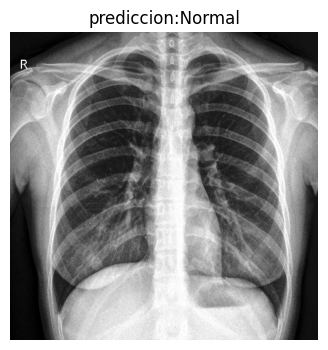

In [65]:
predict(imagen)